# **Data Processing**

In [ ]:
#@title Requirements

import tensorflow as tf
import os

2024-03-26 02:43:37.418496: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-26 02:43:37.418605: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-26 02:43:37.586344: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
#@title Data Cleansing

import cv2
import imghdr
from matplotlib import pyplot as plt

data_dir = ['/kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/colon_image_sets']
os.mkdir(os.path.join('/kaggle/working/','logs'))
os.mkdir(os.path.join('/kaggle/working/','models'))

Found 10000 files belonging to 2 classes.
Batch classes:  [0 1 1 1 0 0 0 0 1 1 0 1 0 0 0 1]


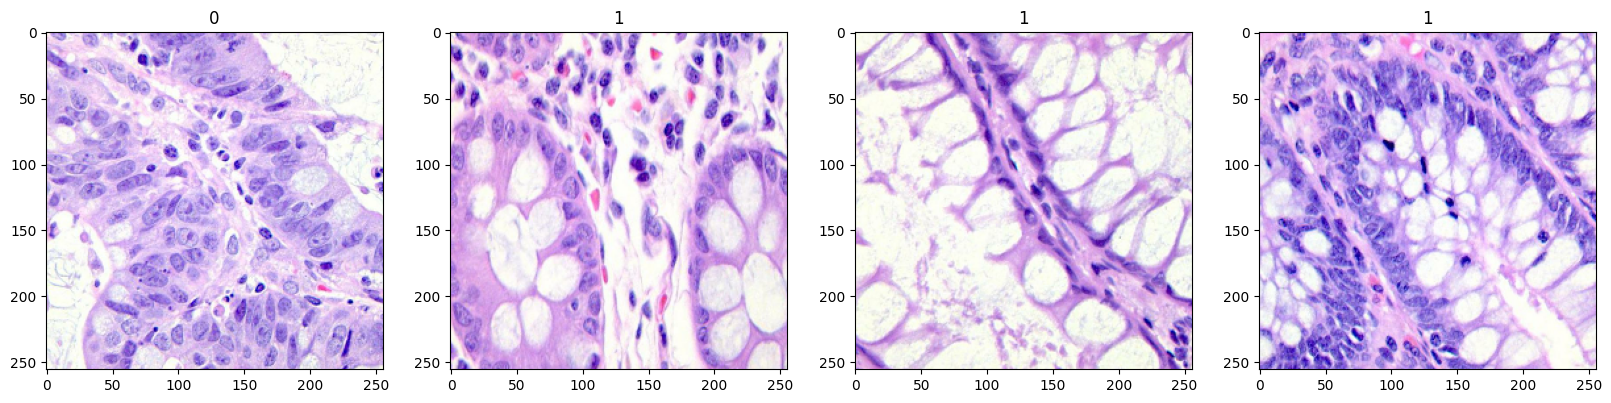

In [ ]:
#@title Creating Data Pipeline
import numpy as np

data = tf.keras.utils.image_dataset_from_directory('/kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/colon_image_sets', batch_size=16, shuffle=True)     # Building data pipeline

data_iterator = data.as_numpy_iterator()        # Helps in accessing data pipeline
batch = data_iterator.next()            # Accessing data pipeline
print("Batch classes: ", batch[1])
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [ ]:
# Access class names
class_names = data.class_names

# Print class names and their corresponding labels
for label, class_name in enumerate(class_names):
    print(f"Label {label}: {class_name}")

Label 0: colon_aca
Label 1: colon_n


In [ ]:
''' Scaling Data '''
# Scaling Data
data = data.map(lambda x,y: (x/255, y))
data.as_numpy_iterator().next()[0].max()


''' Splitting Data '''
train_size = int(len(data)*.7)
val_size = int(len(data)*.1)
test_size = int(len(data)*.2)

train = data.take(train_size)
val = data.take(val_size)
test = data.take(test_size)

print(train_size, "+", test_size, "+", val_size, "=", len(data))

437 + 125 + 62 = 625


In [ ]:
#@title Assigning weights to classes
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm

# images = []
labels = []
# data = []
for batch in tqdm(train.as_numpy_iterator()):
    X1, y1 = batch
    labels.extend(list(y1))

labels = np.array(labels)
print(labels)

# Calculate class weights using scikit-learn's compute_class_weight function
class_weights = compute_class_weight(class_weight = 'balanced', classes = np.unique(labels), y = labels)
class_weights = dict(zip(np.unique(labels), class_weights))

437it [00:19, 22.27it/s]

[1 1 0 ... 0 0 0]


# **Deep Learning Models Creation, Training, Evaluating, Saving, Performance Graph etc.**

In [ ]:
#@title Wave Conversion Layer

from tensorflow.keras.layers import Layer
from tensorflow.keras.layers import Concatenate, Flatten
import numpy as np
import math
from itertools import combinations
import tensorflow_probability as tfp

class WaveConvertLayer(Layer):
    def __init__(self, top=None, mode='pearson', alpha=0.5, beta=0.4, **kwargs):
        super(WaveConvertLayer, self).__init__(**kwargs)
        self.top = top
        self.mode = mode
        self.alpha = alpha
        self.beta = beta

    def pearson_correlation_coefficient(self, tup):
        x = tup[0]
        y = tup[1]
        x_flat = tf.reshape(x, [-1, tf.shape(x)[1] * tf.shape(x)[2] * tf.shape(x)[3]])
        y_flat = tf.reshape(y, [-1, tf.shape(y)[1] * tf.shape(y)[2] * tf.shape(y)[3]])

        # Cosine Similarity
        dot_product = tf.reduce_sum(tf.multiply(x_flat, y_flat), axis=-1, keepdims=True)
        norm_x = tf.norm(x_flat, axis=-1, keepdims=True)
        norm_y = tf.norm(y_flat, axis=-1, keepdims=True)
        cos_similarity = dot_product / (norm_x * norm_y)

        # Pearson Correlation Coefficient
        x_mean = tf.reduce_mean(x_flat, axis=-1, keepdims=True)
        y_mean = tf.reduce_mean(y_flat, axis=-1, keepdims=True)
        X = x_flat - x_mean
        Y = y_flat - y_mean
        pr_similarity = tf.reduce_sum((X*Y), axis=-1, keepdims=True)/tf.sqrt(tf.reduce_sum((X**2), axis=-1, keepdims=True) * tf.reduce_sum((Y**2), axis=-1, keepdims=True))

        # Fused Similarity
        similarity = ((self.alpha * pr_similarity) + cos_similarity)/2.0
        return similarity

    def spearman_rank_correlation(self, tup):
        x = tup[0]
        y = tup[1]
        x_flat = tf.reshape(x, [-1, tf.shape(x)[1] * tf.shape(x)[2] * tf.shape(x)[3]])
        y_flat = tf.reshape(y, [-1, tf.shape(y)[1] * tf.shape(y)[2] * tf.shape(y)[3]])

        # Cosine Similarity
        dot_product = tf.reduce_sum(tf.multiply(x_flat, y_flat), axis=-1, keepdims=True)
        norm_x = tf.norm(x_flat, axis=-1, keepdims=True)
        norm_y = tf.norm(y_flat, axis=-1, keepdims=True)
        cos_similarity = dot_product / (norm_x * norm_y)

        # Spearman Rank Correlation
        d = x_flat - y_flat
        n = x_flat.shape[-1]
        rho = 1 - ((6 * tf.reduce_sum((d**2), axis=-1, keepdims=True))/(n * (n**2 - 1)))

        # Fused Similarity
        similarity = ((self.alpha * rho) + cos_similarity)/2.0
        return similarity

    def similarity_compute(self, mean, *argv):
        L = len(argv)
        arg_shape = argv[0].shape

        similarities = []
        for i, arg in enumerate(argv):
            if self.mode == "pearson":
                sim = self.pearson_correlation_coefficient((mean, arg))
            elif self.mode == "spearman":
                sim = self.spearman_rank_correlation((mean, arg))

            similarities.append(sim)

        similarities = Concatenate(axis=-1)(similarities)
        argv = Concatenate(axis=-1)(argv)
        a = 3.1; h = 1.065; c = 1.1; k = 0.1;
        score = tf.math.exp(a * (similarities - h)) * c + k
        score_reshaped = tf.expand_dims(score, axis=1)
        score_reshaped = tf.expand_dims(score_reshaped, axis=1)
        score_reshaped = tf.tile(score_reshaped, [1, argv.shape[-3], argv.shape[-2], 1])
        filtered_map = argv * score_reshaped

        return filtered_map


    def call(self, inputs):
        l = []
        for i in range(inputs.shape[-1]):
            l.append(tf.expand_dims(inputs[:, :, :, i], axis=-1))

        mean = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        predictions = self.similarity_compute(mean, *l)

        l = []
        for i in range(predictions.shape[-1]):
            l.append(tf.expand_dims(predictions[:, :, :, i], axis=-1))

        flattened_outp = [Flatten()(i) for i in l]
        predictions = tf.stack(flattened_outp, axis=-1)

        return predictions

In [ ]:
''' Deep Model '''
#@title MobileNetV2

import tensorflow as tf
import keras.backend as K
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Layer, Conv2D, MaxPool2D, Dense, Flatten, Dropout, AveragePooling2D, Concatenate, Conv2DTranspose, GlobalAveragePooling2D, BatchNormalization, ReLU, Reshape, Resizing, Add, SeparableConv2D, MultiHeadAttention, UpSampling2D, LayerNormalization, ZeroPadding2D, DepthwiseConv2D, Activation
from tensorflow.keras.layers import LSTM, Bidirectional, Conv1D, MaxPool1D
from tensorflow.keras.applications import Xception, MobileNetV2, DenseNet201, ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.metrics import Recall, Precision, Accuracy
import math

def waveparse(input_x, filters, a, count):
    x = Conv1D(filters[0], 4, strides=2, padding='same', activation='relu', name='conv1d1'+count)(input_x)
    x = MaxPool1D(filters[1], padding='valid', name='pool1D'+count)(x)
    x = Conv1D(filters[3], 4, strides=2, padding='same', activation='relu', name='conv1d2'+count)(x)
    x = Reshape((a, a, x.shape[-1]))(x)
    return x

def mod(img_shape, n_classes):
    input_x = Input(shape=img_shape, name='input_1')

    # Conv1 block
    x = Conv2D(32, (3, 3), strides=(2, 2), padding='same', use_bias=False, name='Conv1')(input_x)
    x = BatchNormalization(name='bn_Conv1')(x)
    x = ReLU(name='Conv1_relu')(x)

    # Expanded Conv block
    x = DepthwiseConv2D((3, 3), strides=(1, 1), padding='same', use_bias=False, name='expanded_conv_depthwise')(x)
    x = BatchNormalization(name='expanded_conv_depthwise_BN')(x)
    x = ReLU(name='expanded_conv_depthwise_relu')(x)
    x = Conv2D(16, (1, 1), strides=(1, 1), padding='same', use_bias=False, name='expanded_conv_project')(x)
    x = BatchNormalization(name='expanded_conv_project_BN')(x)

    # block_1
    x = Conv2D(96, (1, 1), strides=(1, 1), padding='same', name='block_1_expand')(x)
    x = BatchNormalization(name='block_1_expand_BN')(x)
    x = ReLU(name='block_1_expand_relu')(x)
    x = ZeroPadding2D(padding=((1, 0), (1, 0)), name='block_1_pad')(x)
    x = DepthwiseConv2D((3, 3), strides=(2, 2), padding='valid', use_bias=False, name='block_1_depthwise')(x)
    x = BatchNormalization(name='block_1_depthwise_BN')(x)
    x = ReLU(name='block_1_depthwise_relu')(x)
    x = Conv2D(24, (1, 1), strides=(1, 1), padding='same', use_bias=False, name='block_1_project')(x)
    x_1 = BatchNormalization(name='block_1_project_BN')(x)

    # block_2
    x = Conv2D(144, (1, 1), strides=(1, 1), padding='same', use_bias=False, name='block_2_expand')(x_1)
    x = BatchNormalization(name='block_2_expand_BN')(x)
    x = ReLU(name='block_2_expand_relu')(x)
    x = DepthwiseConv2D((3, 3), strides=(1, 1), padding='same', use_bias=False, name='block_2_depthwise')(x)
    x = BatchNormalization(name='block_2_depthwise_BN')(x)
    x = ReLU(name='block_2_depthwise_relu')(x)
    x = Conv2D(24, (1, 1), strides=(1, 1), padding='same', use_bias=False, name='block_2_project')(x)
    x = BatchNormalization(name='block_2_project_BN')(x)
    x = Add(name='block_2_add')([x_1, x])
    x_00 = WaveConvertLayer(top=math.ceil(x.shape[-1]*(95.0/100.0)), mode="pearson", alpha=0.5, beta=0.4, name="pearson_correlation_coef")(x)

    # block_3
    x = Conv2D(144, (1, 1), strides=(1, 1), padding='same', use_bias=False, name='block_3_expand')(x)
    x = BatchNormalization(name='block_3_expand_BN')(x)
    x = ReLU(name='block_3_expand_relu')(x)
    x = ZeroPadding2D(padding=((1, 0), (1, 0)), name='block_3_pad')(x)
    x = DepthwiseConv2D((3, 3), strides=(2, 2), padding='valid', use_bias=False, name='block_3_depthwise')(x)
    x = BatchNormalization(name='block_3_depthwise_BN')(x)
    x = ReLU(name='block_3_depthwise_relu')(x)
    x = Conv2D(32, (1, 1), strides=(1, 1), padding='same', use_bias=False, name='block_3_project')(x)
    x_3 = BatchNormalization(name='block_3_project_BN')(x)

    # block_4
    x = Conv2D(192, (1, 1), strides=(1, 1), padding='same', use_bias=False, name='block_4_expand')(x_3)
    x = BatchNormalization(name='block_4_expand_BN')(x)
    x = ReLU(name='block_4_expand_relu')(x)
    x = DepthwiseConv2D((3, 3), strides=(1, 1), padding='same', use_bias=False, name='block_4_depthwise')(x)
    x = BatchNormalization(name='block_4_depthwise_BN')(x)
    x = ReLU(name='block_4_depthwise_relu')(x)
    x = Conv2D(32, (1, 1), strides=(1, 1), padding='same', use_bias=False, name='block_4_project')(x)
    x = BatchNormalization(name='block_4_project_BN')(x)
    x_4 = Add(name='block_4_add')([x_3, x])
    x_20 = WaveConvertLayer(top=math.ceil(x_4.shape[-1]*(97.0/100.0)), mode="spearman", alpha=0.5, beta=0.5, name="spearman_rank_corre")(x_4)

    # block_5
    x = Conv2D(192, (1, 1), strides=(1, 1), padding='same', use_bias=False, name='block_5_expand')(x_4)
    x = BatchNormalization(name='block_5_expand_BN')(x)
    x = ReLU(name='block_5_expand_relu')(x)
    x = DepthwiseConv2D((3, 3), strides=(1, 1), padding='same', use_bias=False, name='block_5_depthwise')(x)
    x = BatchNormalization(name='block_5_depthwise_BN')(x)
    x = ReLU(name='block_5_depthwise_relu')(x)
    x = Conv2D(32, (1, 1), strides=(1, 1), padding='same', use_bias=False, name='block_5_project')(x)
    x = BatchNormalization(name='block_5_project_BN')(x)
    x = Add(name='block_5_add')([x_4, x])

    # block_6
    x = Conv2D(192, (1, 1), strides=(1, 1), padding='same', use_bias=False, name='block_6_expand')(x)
    x = BatchNormalization(name='block_6_expand_BN')(x)
    x = ReLU(name='block_6_expand_relu')(x)
    x = ZeroPadding2D(padding=((1, 0), (1, 0)), name='block_6_pad')(x)
    x = DepthwiseConv2D((3, 3), strides=(2, 2), padding='valid', use_bias=False, name='block_6_depthwise')(x)
    x = BatchNormalization(name='block_6_depthwise_BN')(x)
    x = ReLU(name='block_6_depthwise_relu')(x)
    x = Conv2D(64, (1, 1), strides=(1, 1), padding='same', use_bias=False, name='block_6_project')(x)
    x_6 = BatchNormalization(name='block_6_project_BN')(x)

    # block_7
    x = Conv2D(384, (1, 1), strides=(1, 1), padding='same', use_bias=False, name='block_7_expand')(x_6)
    x = BatchNormalization(name='block_7_expand_BN')(x)
    x = ReLU(name='block_7_expand_relu')(x)
    x = DepthwiseConv2D((3, 3), strides=(1, 1), padding='same', use_bias=False, name='block_7_depthwise')(x)
    x = BatchNormalization(name='block_7_depthwise_BN')(x)
    x = ReLU(name='block_7_depthwise_relu')(x)
    x = Conv2D(64, (1, 1), strides=(1, 1), padding='same', use_bias=False, name='block_7_project')(x)
    x = BatchNormalization(name='block_7_project_BN')(x)
    x_7 = Add(name='block_7_add')([x_6, x])

    # block_8
    x = Conv2D(384, (1, 1), strides=(1, 1), padding='same', use_bias=False, name='block_8_expand')(x_7)
    x = BatchNormalization(name='block_8_expand_BN')(x)
    x = ReLU(name='block_8_expand_relu')(x)
    x = DepthwiseConv2D((3, 3), strides=(1, 1), padding='same', use_bias=False, name='block_8_depthwise')(x)
    x = BatchNormalization(name='block_8_depthwise_BN')(x)
    x = ReLU(name='block_8_depthwise_relu')(x)
    x = Conv2D(64, (1, 1), strides=(1, 1), padding='same', use_bias=False, name='block_8_project')(x)
    x = BatchNormalization(name='block_8_project_BN')(x)
    x_8 = Add(name='block_8_add')([x_7, x])

    # block_9
    x = Conv2D(384, (1, 1), strides=(1, 1), padding='same', use_bias=False, name='block_9_expand')(x_8)
    x = BatchNormalization(name='block_9_expand_BN')(x)
    x = ReLU(name='block_9_expand_relu')(x)
    x = DepthwiseConv2D((3, 3), strides=(1, 1), padding='same', use_bias=False, name='block_9_depthwise')(x)
    x = BatchNormalization(name='block_9_depthwise_BN')(x)
    x = ReLU(name='block_9_depthwise_relu')(x)
    x = Conv2D(64, (1, 1), strides=(1, 1), padding='same', use_bias=False, name='block_9_project')(x)
    x = BatchNormalization(name='block_9_project_BN')(x)
    x = Add(name='block_9_add')([x_8, x])
    x_20 = Conv1D(64, 4, strides=2, padding='same', activation='relu', name='conv1d2')(x_20)
    x_20 = Conv1D(64, 4, strides=2, padding='same', activation='relu', name='conv1d22')(x_20)
    x_20 = Reshape((x.shape[-2], x.shape[-2], x.shape[-1]))(x_20)
    x = x * x_20

    # block_10
    x = Conv2D(384, (1, 1), strides=(1, 1), padding='same', use_bias=False, name='block_10_expand')(x)
    x = BatchNormalization(name='block_10_expand_BN')(x)
    x = ReLU(name='block_10_expand_relu')(x)
    x = DepthwiseConv2D((3, 3), strides=(1, 1), padding='same', use_bias=False, name='block_10_depthwise')(x)
    x = BatchNormalization(name='block_10_depthwise_BN')(x)
    x = ReLU(name='block_10_depthwise_relu')(x)
    x = Conv2D(96, (1, 1), strides=(1, 1), padding='same', use_bias=False, name='block_10_project')(x)
    x_10 = BatchNormalization(name='block_10_project_BN')(x)

    # block_11
    x = Conv2D(576, (1, 1), padding='same', use_bias=False, name='block_11_expand')(x_10)
    x = BatchNormalization(name='block_11_expand_BN')(x)
    x = ReLU(name='block_11_expand_relu')(x)
    x = DepthwiseConv2D((3, 3), padding='same', use_bias=False, name='block_11_depthwise')(x)
    x = BatchNormalization(name='block_11_depthwise_BN')(x)
    x = ReLU(name='block_11_depthwise_relu')(x)
    x = Conv2D(96, (1, 1), padding='same', use_bias=False, name='block_11_project')(x)
    x = BatchNormalization(name='block_11_project_BN')(x)
    x_11 = Add(name='block_11_add')([x_10, x])
    x_00 = waveparse(x_00, [64, 4, 64, 96], x_11.shape[-2], "_1")
    x_11 = x_11 * x_00

    # block_12
    x = Conv2D(576, (1, 1), padding='same', use_bias=False, name='block_12_expand')(x_11)
    x = BatchNormalization(name='block_12_expand_BN')(x)
    x = ReLU(name='block_12_expand_relu')(x)
    x = DepthwiseConv2D((3, 3), padding='same', use_bias=False, name='block_12_depthwise')(x)
    x = BatchNormalization(name='block_12_depthwise_BN')(x)
    x = ReLU(name='block_12_depthwise_relu')(x)
    x = Conv2D(96, (1, 1), padding='same', use_bias=False, name='block_12_project')(x)
    x = BatchNormalization(name='block_12_project_BN')(x)
    x = Add(name='block_12_add')([x_11, x])

    # block_13
    x = Conv2D(576, (1, 1), padding='same', use_bias=False, name='block_13_expand')(x)
    x = BatchNormalization(name='block_13_expand_BN')(x)
    x = ReLU(name='block_13_expand_relu')(x)
    x = tf.keras.layers.ZeroPadding2D(padding=((0, 1), (0, 1)), name='block_13_pad')(x)
    x = DepthwiseConv2D((3, 3), strides=(2, 2), padding='valid', use_bias=False, name='block_13_depthwise')(x)
    x = BatchNormalization(name='block_13_depthwise_BN')(x)
    x = ReLU(name='block_13_depthwise_relu')(x)
    x = Conv2D(160, (1, 1), padding='same', use_bias=False, name='block_13_project')(x)
    x_13 = BatchNormalization(name='block_13_project_BN')(x)

    # block_14
    x = Conv2D(960, (1, 1), padding='same', use_bias=False, name='block_14_expand')(x_13)
    x = BatchNormalization(name='block_14_expand_BN')(x)
    x = ReLU(name='block_14_expand_relu')(x)
    x = DepthwiseConv2D((3, 3), padding='same', use_bias=False, name='block_14_depthwise')(x)
    x = BatchNormalization(name='block_14_depthwise_BN')(x)
    x = ReLU(name='block_14_depthwise_relu')(x)
    x = Conv2D(160, (1, 1), padding='same', use_bias=False, name='block_14_project')(x)
    x = BatchNormalization(name='block_14_project_BN')(x)
    x_14 = Add(name='block_14_add')([x_13, x])

    # block_15
    x = Conv2D(960, (1, 1), padding='same', use_bias=False, name='block_15_expand')(x_14)
    x = BatchNormalization(name='block_15_expand_BN')(x)
    x = ReLU(name='block_15_expand_relu')(x)
    x = DepthwiseConv2D((3, 3), padding='same', use_bias=False, name='block_15_depthwise')(x)
    x = BatchNormalization(name='block_15_depthwise_BN')(x)
    x = ReLU(name='block_15_depthwise_relu')(x)
    x = Conv2D(160, (1, 1), padding='same', use_bias=False, name='block_15_project')(x)
    x = BatchNormalization(name='block_15_project_BN')(x)
    x = Add(name='block_15_add')([x_14, x])

    # block_16
    x = Conv2D(960, (1, 1), padding='same', use_bias=False, name='block_16_expand')(x)
    x = BatchNormalization(name='block_16_expand_BN')(x)
    x = ReLU(name='block_16_expand_relu')(x)
    x = DepthwiseConv2D((3, 3), padding='same', use_bias=False, name='block_16_depthwise')(x)
    x = BatchNormalization(name='block_16_depthwise_BN')(x)
    x = ReLU(name='block_16_depthwise_relu')(x)
    x = Conv2D(320, (1, 1), padding='same', use_bias=False, name='block_16_project')(x)
    x = BatchNormalization(name='block_16_project_BN')(x)

    # Final
    x = Conv2D(1280, (1, 1), padding='same', use_bias=False, name='Conv_1')(x)
    x = BatchNormalization(name='Conv_1_bn')(x)
    x = ReLU(name='out_relu')(x)

    # Outputs
    x = GlobalAveragePooling2D()(x)
    x = Dropout(rate = 0.2)(x)
    x = Dense(n_classes, activation='softmax')(x)

    model = Model(inputs=input_x, outputs=x, name="MobileNetV2CRNN")
    return model

input_shape = (256, 256, 3)
n_classes = 2

model = mod(input_shape, n_classes)
model.compile(tf.keras.optimizers.Adam(learning_rate=0.00001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "MobileNetV2CRNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_1             │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,632 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 2,316,226 (8.84 MB)

 Trainable params: 2,282,114 (8.71 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
#@title Training the Models

# Train
logdir='/content/drive/My Drive/Colab Notebooks/logs'
tensorboard_callback1 = tf.keras.callbacks.TensorBoard(log_dir=logdir)
tensorboard_callback2 = tf.keras.callbacks.ModelCheckpoint(
    filepath='/kaggle/working/model.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
    )

hist = model.fit(train, epochs=120, class_weight=class_weights, validation_data=val, callbacks=[tensorboard_callback1, tensorboard_callback2])
print(hist.history)

Epoch 1/120


W0000 00:00:1711426116.395274      91 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5843 - loss: 0.6797

W0000 00:00:1711426164.271198      93 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update



Epoch 1: val_accuracy improved from -inf to 0.47984, saving model to /kaggle/working/model.weights.h5
437/437 ━━━━━━━━━━━━━━━━━━━━ 140s 112ms/step - accuracy: 0.5844 - loss: 0.6797 - val_accuracy: 0.4798 - val_loss: 1.2236
Epoch 2/120
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.6978 - loss: 0.5748
Epoch 2: val_accuracy improved from 0.47984 to 0.67742, saving model to /kaggle/working/model.weights.h5
437/437 ━━━━━━━━━━━━━━━━━━━━ 37s 83ms/step - accuracy: 0.6979 - loss: 0.5747 - val_accuracy: 0.6774 - val_loss: 0.5747
Epoch 3/120
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.7971 - loss: 0.4358
Epoch 3: val_accuracy improved from 0.67742 to 0.85282, saving model to /kaggle/working/model.weights.h5
437/437 ━━━━━━━━━━━━━━━━━━━━ 38s 86ms/step - accuracy: 0.7972 - loss: 0.4357 - val_accuracy: 0.8528 - val_loss: 0.3403
Epoch 4/120
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8352 - loss: 0.3718
Epoch 4: val_accuracy improved from 0.85282 to 0.88306, saving m

125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 1.0000 - loss: 1.5748e-04
Result : 
 1.0
Loss: 
 0.0001511003792984411
For MobileNetV2: 


W0000 00:00:1711425734.741421      93 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


Precision:1.0, Recall:1.0, Accuracy (Binary):1.0, Accuracy (sparse_categorical):[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Confusion Matrix for Model: 
 [[9 0]
 [0 7]]


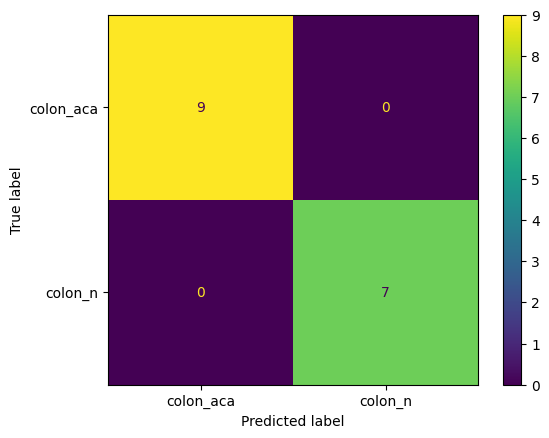

For Test Dataset: 
Precision:1.0, Recall:1.0, Accuracy (Binary):1.0
Confusion Matrix for MobileNetV2 on Test Dataset: 
 [[ 973    0]
 [   0 1027]]


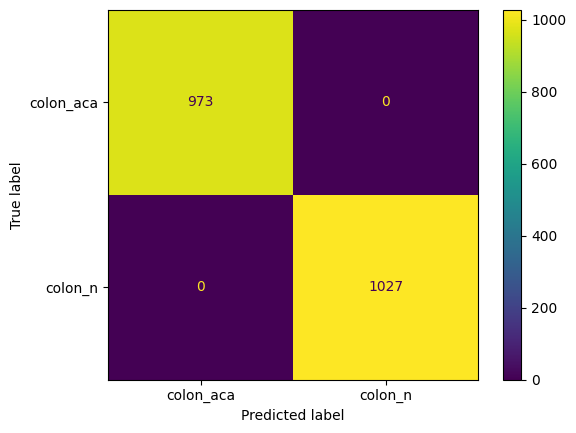

In [ ]:
#@title Evaluating the Model

''' Evaluation '''
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy, sparse_categorical_accuracy
from sklearn.metrics import *

model.load_weights("/kaggle/working/model.weights.h5")
loss, results = model.evaluate(test, batch_size=328, callbacks=[tensorboard_callback1, tensorboard_callback2])
print("Result : \n", results)
print("Loss: \n", loss)

''' MobileNetV2 '''
print("For MobileNetV2: ")
pre = Precision()
re = Recall()
acc = BinaryAccuracy()
labels = []
predicts = []
pre3 = Precision()
re3 = Recall()
acc3 = BinaryAccuracy()
for batch3 in test.as_numpy_iterator():
    X3, y3 = batch3
    labels.extend(list(y3))
    yhat3 = model.predict(X3, verbose=0)
    max = a = 0
    arr = np.ones(yhat3.shape[0])*-1
    for i in yhat3:
        max = np.argmax(i)
        arr[a] = max
        a+=1
    predicts.extend(list(arr))
    pre3.update_state(y3, arr)
    re3.update_state(y3, arr)
    acc3.update_state(y3, arr)
acc31 = sparse_categorical_accuracy(y3, yhat3)
assert acc31.shape == (y3.shape[0],)
print(f'Precision:{pre3.result().numpy()}, Recall:{re3.result().numpy()}, Accuracy (Binary):{acc3.result().numpy()}, Accuracy (sparse_categorical):{acc31.numpy()}')
matrix = confusion_matrix(y3, arr)
print("Confusion Matrix for Model: \n", matrix)
display = ConfusionMatrixDisplay(confusion_matrix = matrix, display_labels = os.listdir("/kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/colon_image_sets")) #['Benign', 'Malignant'])
display.plot()
plt.show()

print("For Test Dataset: ")
pre.update_state(labels, predicts)
re.update_state(labels, predicts)
acc.update_state(labels, predicts)
print(f'Precision:{pre.result().numpy()}, Recall:{re.result().numpy()}, Accuracy (Binary):{acc.result().numpy()}')
matrix = confusion_matrix(labels, predicts)
print("Confusion Matrix for MobileNetV2 on Test Dataset: \n", matrix)
display = ConfusionMatrixDisplay(confusion_matrix = matrix, display_labels = os.listdir("/kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/colon_image_sets")) #['Benign', 'Malignant'])
display.plot()
plt.show()

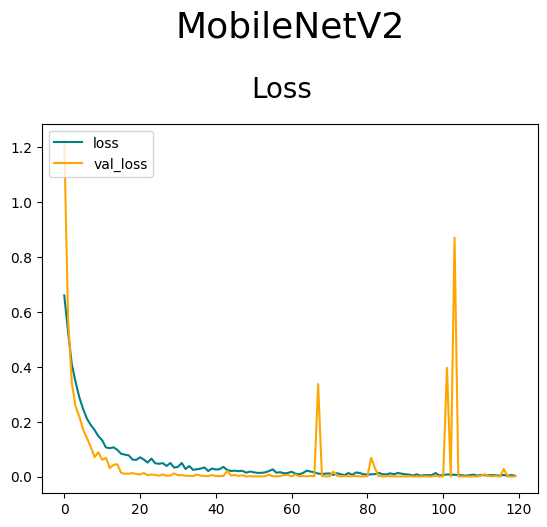

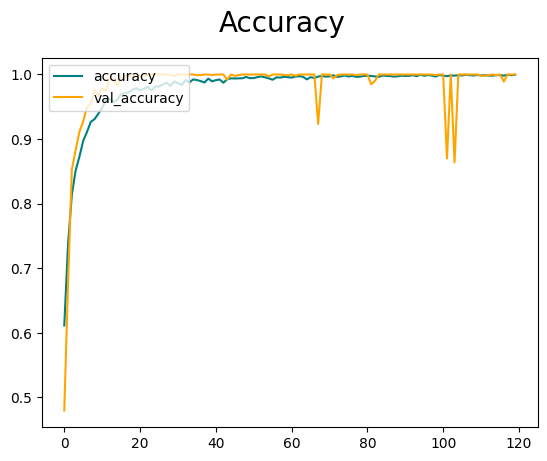

In [ ]:
#@title Performance Graphs

import matplotlib.pyplot as plt

# Loss
fig = plt.figure()
plt.title("MobileNetV2\n\n", loc='center', fontsize=26)
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

# Accuracy
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [ ]:
#@title ROC-AUC Curves

import pandas as pd
import numpy as np
from sklearn.metrics import *
import math, os
from sklearn.preprocessing import label_binarize

#ROC-AUC
from sklearn.metrics import roc_curve,auc
import matplotlib.pyplot as plt
def plot_roc(val_label,decision_val, caption='ROC Curve'):
    num_classes=np.unique(val_label).shape[0]
    classes = []
    for i in range(num_classes):
        classes.append(i)
    plt.figure()
    decision_val = label_binarize(decision_val, classes=classes)

    if num_classes!=2:
        # Compute ROC curve and ROC area for each class
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        for i in range(num_classes):
            y_val = label_binarize(val_label, classes=classes)
            fpr[i], tpr[i], _ = roc_curve(y_val[:, i], decision_val[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
        for i in range(num_classes):
            plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'
                                           ''.format(i+1, roc_auc[i]))
    else:
        fpr,tpr,_ = roc_curve(val_label,decision_val, pos_label=1)
        roc_auc = auc(fpr,tpr)*100
        plt.plot(fpr,tpr,label='ROC curve (AUC=%0.2f)'%roc_auc)

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(caption)
    plt.legend(loc="lower right",  bbox_to_anchor=(1, 0.5))
    plt.savefig(str(len(classes))+'.png',dpi=300)

def predicting(ensemble_prob):
    prediction = np.zeros((ensemble_prob.shape[0],))
    for i in range(ensemble_prob.shape[0]):
        temp = ensemble_prob[i]
        t = np.where(temp == np.max(temp))[0][0]
        prediction[i] = t
    return prediction

def metrics(labels, predictions, classes, display_label):
    print("Classification Report:")
    print("Labels : ",labels.shape, '\nPredictions : ', predictions.shape)
    print(classification_report(labels, predictions, target_names = classes, digits = 4))
    matrix = confusion_matrix(labels, predictions)
    print("Confusion matrix:")
    print(matrix)
    plt.figure()
    display = ConfusionMatrixDisplay(confusion_matrix = matrix, display_labels = display_label)
    display.plot()
    plt.xticks(rotation=50)
    plt.show()
    print("\nClasswise Accuracy :{}".format(matrix.diagonal()/matrix.sum(axis = 1)))
    print("\nBalanced Accuracy Score: ",balanced_accuracy_score(labels,predictions))


MobileNetV2 : 1 0 0 1 0 1 1 0 0 1 1 1 1 0 0 1 0 0 0 1 0 1 1 0 0 1 0 0 0 0 1 0 1 1 0 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 0 1 0 0 0 0 0 1 1 0 1 0 0 0 1 1 1 0 0 0 1 1 0 1 0 0 1 1 1 0 0 1 1 1 0 1 0 0 1 0 0 1 0 1 1 1 0 1 1 0 0 1 0 1 1 1 0 1 1 1 1 0 0 0 1 1 1 0 0 0 1 1 0 1 1 1 0 0 0 1 0 1 0 0 0 0 0 0 1 1 1 1 0 0 1 1 0 1 0 0 0 0 1 1 1 0 1 1 1 0 1 0 0 0 1 0 0 1 1 0 0 1 0 0 1 1 1 0 1 1 1 1 0 1 1 1 0 1 0 1 1 0 1 1 0 1 1 1 1 0 1 1 0 0 1 0 1 0 0 0 0 1 1 1 1 0 0 0 0 0 0 1 1 0 1 1 0 1 0 1 0 0 0 0 1 0 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 0 1 1 0 0 0 1 0 0 1 1 1 0 0 1 1 0 1 1 1 1 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 0 0 1 1 0 1 0 1 0 0 1 0 1 1 0 1 0 0 1 1 1 1 0 0 1 0 1 1 1 0 1 1 0 1 0 1 1 0 1 1 1 0 1 1 0 1 1 1 0 1 1 1 1 0 1 1 0 0 0 0 1 0 1 0 1 1 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 1 0 0 1 0 1 1 1 0 1 1 0 0 1 1 0 1 0 1 0 1 0 1 1 1 1 0 0 1 0 1 0 0 1 1 0 1 1 0 1 1 1 0 1 1 1 1 1 0 0 0 0 1 0 0 0 1 0 0 1 1 1 1 1 1 1 1 1 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0 1 0 1 1 0 0 1 1 0 0 0 0 1 0 1 1 1 0 0 1 1 0 0 1 0 0 1

<Figure size 640x480 with 0 Axes>

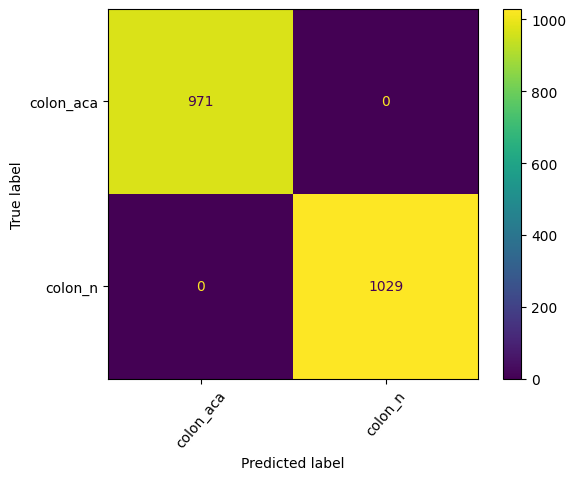


Classwise Accuracy :[1. 1.]

Balanced Accuracy Score:  1.0
Accuracy[1.0000] Precision[1.0000] Recall[1.0000] F1[1.0000] ]
________________________________________________________________


Overall Accuracy[1.0000] Overall Precision[1.0000] Overall Recall[1.0000] Overall F1[1.0000]


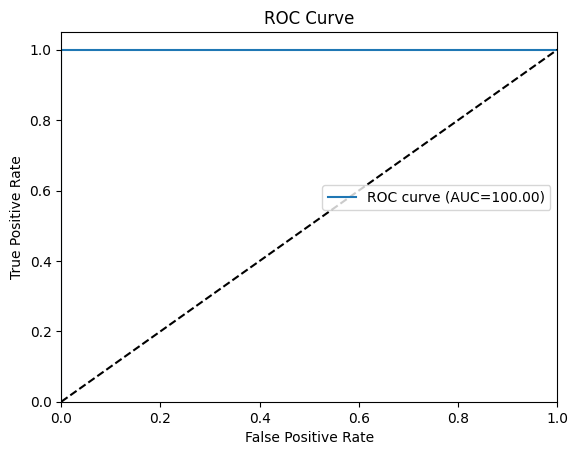

In [ ]:
#@title Precision, Recall and Accuracy of the Models with respect to test dataset

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

labels = []
p = []
p1 = []
for batch in test.as_numpy_iterator():
    X, y = batch
    labels.extend(list(y))
    yhat = model.predict(X, verbose=0)
    max = 0
    for i in yhat:
        max = np.argmax(i)
        p.append(max)
        p1.append(i)

labels = np.asarray(labels)
p = np.asarray(p)

import csv
fp = open("/kaggle/working/test.csv",'w+',newline = '')
writer = csv.writer(fp)
for i in p1:
    writer.writerow([i[0], i[1]])
fp.close()

fp = open("/kaggle/working/labels.csv",'w+',newline = '')
writer = csv.writer(fp)
for i in labels:
    writer.writerow([i])
fp.close()

print("\nMobileNetV2 : ", end="")
for i in p:
    print(i, end=" ")
print()


print("For MobileNetV2 : ")
# metrics(labels, p, ['1', '2'], ['Normal', 'OSCC'])
metrics(labels, p, list(map(str, range(1, 3))), os.listdir("/kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/colon_image_sets"))
plot_roc(labels, p)

avg_acc_list = []
avg_precision_list = []
avg_recall_list = []
avg_f1_list = []

acc_fold = accuracy_score(labels, p)
avg_acc_list.append(acc_fold)
precision_fold = precision_score(labels, p, average='macro')
avg_precision_list.append(precision_fold)
recall_fold = recall_score(labels, p, average='macro')
avg_recall_list.append(recall_fold)
f1_fold  = f1_score(labels, p, average='macro')
avg_f1_list.append(f1_fold)

print('Accuracy[{:.4f}] Precision[{:.4f}] Recall[{:.4f}] F1[{:.4f}] ]'.format(acc_fold, precision_fold, recall_fold, f1_fold ))
print('________________________________________________________________')

avg_acc = np.asarray(avg_acc_list)
avg_pre = np.asarray(avg_precision_list)
avg_recall = np.asarray(avg_recall_list)
avg_f1 = np.asarray(avg_f1_list)
print("\n")
print('Overall Accuracy[{:.4f}] Overall Precision[{:.4f}] Overall Recall[{:.4f}] Overall F1[{:.4f}]'.format(np.mean(avg_acc), np.mean(avg_pre), np.mean(avg_recall), np.mean(avg_f1)))